# 03.1 Visuelle Ergebnistabellen für Kapitel 5.2

Dieses Notebook erzeugt publikationsreife Tabellen für Kapitel 5.2 der Masterarbeit auf Basis der finalen Dateien `99_AI_AND_REAL_TIKTOK_VIDEOS_group_differences.csv` und `99_AI_AND_REAL_TIKTOK_VIDEOS_engagement_correlations.csv`.

Abgedeckt werden die vier analytischen Teilbereiche:

- `5.2.1` Strukturale Inszenierung und visuelle Dynamik
- `5.2.2` Bildtechnische Qualität (H2)
- `5.2.3` Ästhetik (H3)
- `5.2.4` Emotion und soziale Präsenz (H4)
- signifikante Korrelationen mit Engagement

Die Tabellen verwenden ein einheitliches Layout, präzise Spaltenüberschriften und konsistente Anmerkungen. Die p-Wert-Spalten benennen den zugrunde liegenden statistischen Test explizit. Signifikante Gruppenunterschiede und Korrelationen werden mit `*` markiert und dezent hervorgehoben.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
    },
)


In [2]:
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != '05_notebooks':
    NOTEBOOK_DIR = Path('data/05_notebooks').resolve()

DATA_DIR = NOTEBOOK_DIR.parent
RESULTS_DIR = DATA_DIR / '04_analysis_results' / 'visual_features'
OUTPUT_DIR = RESULTS_DIR / 'chapter_tables'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GROUP_DIFF_CSV = RESULTS_DIR / '99_AI_AND_REAL_TIKTOK_VIDEOS_group_differences.csv'
ENGAGEMENT_CORR_CSV = RESULTS_DIR / '99_AI_AND_REAL_TIKTOK_VIDEOS_engagement_correlations.csv'
assert GROUP_DIFF_CSV.exists(), f'Datei nicht gefunden: {GROUP_DIFF_CSV}'
assert ENGAGEMENT_CORR_CSV.exists(), f'Datei nicht gefunden: {ENGAGEMENT_CORR_CSV}'

group_diff_df = pd.read_csv(GROUP_DIFF_CSV)
group_diff_df['signifikant_05'] = group_diff_df['signifikant_05'].astype(str).str.lower().eq('true')

engagement_corr_df = pd.read_csv(ENGAGEMENT_CORR_CSV)
engagement_corr_df['signifikant_05'] = engagement_corr_df['signifikant_05'].astype(str).str.lower().eq('true')

print(f'Daten geladen: {len(group_diff_df)} Gruppenvergleiche aus {GROUP_DIFF_CSV.name}')
print(f'Daten geladen: {len(engagement_corr_df)} Engagement-Korrelationen aus {ENGAGEMENT_CORR_CSV.name}')


Daten geladen: 38 Gruppenvergleiche aus 99_AI_AND_REAL_TIKTOK_VIDEOS_group_differences.csv
Daten geladen: 38 Engagement-Korrelationen aus 99_AI_AND_REAL_TIKTOK_VIDEOS_engagement_correlations.csv


In [3]:
TABLE_SPECS = [
    {
        'chapter': '5.2.1',
        'title': 'Strukturale Inszenierung und visuelle Dynamik',
        'file_stub': '5_2_1_strukturale_inszenierung_und_visuelle_dynamik',
        'sections': [
            ('5.2.1.1', 'Kamerastabilität', ['camera_stability']),
            ('5.2.1.2', 'Schnittdynamik', ['cuts']),
            ('5.2.1.3', 'Kameradistanz', ['camera_distance']),
            ('5.2.1.4', 'Szenenklassifikation', ['scene_classification']),
        ],
    },
    {
        'chapter': '5.2.2',
        'title': 'Bildtechnische Qualität (H2)',
        'file_stub': '5_2_2_bildtechnische_qualität',
        'sections': [
            ('5.2.2.1', 'Helligkeit und Kontrast', ['brightness_contrast']),
            ('5.2.2.2', 'Farbsättigung', ['saturation']),
            ('5.2.2.3', 'Bildschärfe', ['visual_sharpness']),
        ],
    },
    {
        'chapter': '5.2.3',
        'title': 'Ästhetik (H3)',
        'file_stub': '5_2_3_aesthetik',
        'sections': [
            ('5.2.3.1', 'Filtereinsatz', ['visual_filter']),
            ('5.2.3.2', 'Hautglätte', ['skin_smoothness']),
            ('5.2.3.3', 'Attraktivitätsbewertung', ['beauty_scoring']),
            ('5.2.3.4', 'Ästhetische Qualität', ['aesthetic_quality']),
        ],
    },
    {
        'chapter': '5.2.4',
        'title': 'Emotion und soziale Präsenz (H4)',
        'file_stub': '5_2_4_emotion_und_soziale_praesenz',
        'sections': [
            ('5.2.4.1', 'Gesichtsemotionen', ['face_emotion']),
            ('5.2.4.2', 'Körperpose', ['body_pose']),
            ('5.2.4.3', 'Personenanzahl im Bild', ['structural_personen_anzahl']),
            ('5.2.4.4', 'Gesichtsorientierung', ['angle_face_orientation']),
        ],
    },
]

METRIC_ORDER = {
    'camera_stability': ['stability_index', 'optical_flow_magnitude_mean', 'optical_flow_magnitude_std'],
    'cuts': ['cut_count', 'cuts_per_frame', 'cuts_per_second', 'video_duration_seconds_est', 'frames_scanned', 'video_fps'],
    'camera_distance': ['camera_distance_unique_labels'],
    'scene_classification': ['scene_unique_labels'],
    'brightness_contrast': ['brightness_index', 'contrast_index'],
    'saturation': ['saturation_index'],
    'visual_sharpness': ['sharpness_laplacian_mean', 'sharpness_laplacian_std'],
    'visual_filter': ['filter_strength_prob', 'filter_strength_std'],
    'skin_smoothness': [
        'detected_skin_face_frames',
        'skin_smoothness_highpass_index',
        'skin_smoothness_dog_index',
        'skin_texture_laplacian_var',
        'skin_texture_highpass_var',
        'skin_texture_dog_var',
    ],
    'beauty_scoring': ['beauty_detected_face_frames', 'beauty_score_mean', 'beauty_score_std'],
    'aesthetic_quality': ['aesthetic_quality_scored_frames', 'aesthetic_quality_score'],
    'face_emotion': ['detected_emotion_frames', 'emotion_unique_labels'],
    'body_pose': ['detected_pose_frames'],
    'structural_personen_anzahl': ['detected_person_frames', 'personen_anzahl', 'personen_anzahl_max'],
    'angle_face_orientation': ['detected_face_frames', 'face_pitch_mean', 'face_yaw_mean'],
}

SECTION_COLOR_MAP = {
    '5.2.1.1': '#fbfbf8',
    '5.2.1.2': '#f7f5f0',
    '5.2.1.3': '#fbfbf8',
    '5.2.1.4': '#f7f5f0',
    '5.2.2.1': '#fbfbf8',
    '5.2.2.2': '#f7f5f0',
    '5.2.2.3': '#fbfbf8',
    '5.2.3.1': '#fbfbf8',
    '5.2.3.2': '#f7f5f0',
    '5.2.3.3': '#fbfbf8',
    '5.2.3.4': '#f7f5f0',
    '5.2.4.1': '#fbfbf8',
    '5.2.4.2': '#f7f5f0',
    '5.2.4.3': '#fbfbf8',
    '5.2.4.4': '#f7f5f0',
}


In [4]:
import textwrap

TABLE_COLUMNS = ['Kategorie', 'Unterkategorie', 'M (VI)', 'M (RI)', 'U (Mann-Whitney)', 'p (Mann-Whitney-U)', "Cohen's d", 'Richtung']
CORRELATION_COLUMNS = ['Kategorie', 'Unterkategorie', 'rho (Spearman)', 'p (Spearman)', 'Richtung']
TABLE_NOTE = (
    'Anmerkung. VI = virtuelle/KI-generierte Influencer-Videos; RI = reale Influencer-Videos. '
    'Die p-Werte beziehen sich auf zweiseitige Mann-Whitney-U-Tests für Gruppenunterschiede zwischen VI und RI. '
    'Ein Stern (*) kennzeichnet signifikante Gruppenunterschiede (p < .05). '
    "Positive Werte von Cohen's d weisen auf höhere Werte bei RI hin, negative Werte auf höhere Werte bei VI."
)
CORRELATION_NOTE = (
    'Anmerkung. Die Tabelle enthält ausschließlich signifikante Zusammenhänge mit der Engagement-Rate (p < .05). '
    'rho und p beziehen sich auf zweiseitige Spearman-Rangkorrelationen. '
    'Positive rho-Werte zeigen, dass höhere Metrikwerte mit höherem Engagement einhergehen; negative Werte zeigen einen gegenläufigen Zusammenhang.'
)


def prettify_text(text: str) -> str:
    replacements = {
        'Kamerastabilitaet': 'Kamerastabilität',
        'Qualität': 'Qualität',
        'Ästhetische': 'Ästhetische',
        'Ästhetik': 'Ästhetik',
        'Praesenz': 'Präsenz',
        'Koerper': 'Körper',
        'Farbsaettigung': 'Farbsättigung',
        'Bildschaerfe': 'Bildschärfe',
        'Geschaetzte': 'Geschätzte',
        'Gesichtsorientierung': 'Gesichtsorientierung',
        'Stabilitaetsindex': 'Stabilitätsindex',
        'Bewegungsstaerke': 'Bewegungsstärke',
        'Filterstaerke': 'Filterstärke',
        'Durchschnittliche Bildschaerfe': 'Durchschnittliche Bildschärfe',
        'Streuung der Bildschaerfe': 'Streuung der Bildschärfe',
        'Attraktivitaetsbewertung': 'Attraktivitätsbewertung',
        'Ästhetische Qualitätsbewertung': 'Ästhetische Qualitätsbewertung',
        'Hautglaette': 'Hautglätte',
        'Für': 'Für',
        'Wahrscheinlichkeit für Filtereinsatz': 'Wahrscheinlichkeit für Filtereinsatz',
        'Anteil aesthetisch bewerteter Frames': 'Anteil ästhetisch bewerteter Frames',
        'hoeher': 'höher',
    }
    for old, new in replacements.items():
        text = str(text).replace(old, new)
    return text


def short_metric_label(full_label: str) -> str:
    if ' | ' in full_label:
        return full_label.split(' | ', 1)[1]
    return full_label


def format_p_value(value: float) -> str:
    if pd.isna(value):
        return ''
    return '< .001' if value < 0.001 else f'{value:.3f}'


def format_mean(value: float) -> str:
    return '' if pd.isna(value) else f'{value:.2f}'


def format_u_value(value: float) -> str:
    return '' if pd.isna(value) else f'{value:.0f}'


def format_rho(value: float) -> str:
    return '' if pd.isna(value) else f'{value:.3f}'


def chapter_caption(spec: dict) -> str:
    return f"Tabelle {spec['chapter']}: Deskriptive Kennwerte und Gruppenvergleiche - {prettify_text(spec['title'])}"


def correlation_caption() -> str:
    return 'Tabelle 5.2.5: Signifikante Spearman-Korrelationen mit Engagement'


def wrap_for_figure(value: str, width: int) -> str:
    return '\n'.join(textwrap.wrap(str(value), width=width, break_long_words=False))


def prepare_table_df(source_df: pd.DataFrame, spec: dict) -> pd.DataFrame:
    rows = []
    for section_no, section_title, feature_groups in spec['sections']:
        for feature_group in feature_groups:
            sub = source_df[source_df['feature_group'] == feature_group].copy()
            if sub.empty:
                continue

            order = {metric: idx for idx, metric in enumerate(METRIC_ORDER.get(feature_group, []))}
            sub['metric_order'] = sub['metric_name'].map(order).fillna(999).astype(int)
            sub = sub.sort_values(['metric_order', 'p', 'Kategorie']).copy()

            for _, row in sub.iterrows():
                metric_label = prettify_text(short_metric_label(row['Kategorie']))
                metric_label = f'{metric_label}*' if row['signifikant_05'] else metric_label
                rows.append({
                    'Kategorie': prettify_text(section_title),
                    'Unterkategorie': metric_label,
                    'M (VI)': format_mean(row['KI (M)']),
                    'M (RI)': format_mean(row['REAL (M)']),
                    'U (Mann-Whitney)': format_u_value(row['U']),
                    'p (Mann-Whitney-U)': format_p_value(row['p']),
                    "Cohen's d": format_mean(row['Effektgroesse_d']),
                    'Richtung': prettify_text(row['Richtung'].replace('REAL', 'RI').replace('KI', 'VI')),
                    '_significant': bool(row['signifikant_05']),
                    '_section_no': section_no,
                })

    return pd.DataFrame(rows)


def prepare_correlation_table_df(source_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    significant_df = source_df[source_df['signifikant_05']].copy()
    significant_df['abs_rho'] = significant_df['rho_engagement'].abs()
    significant_df = significant_df.sort_values(['p_engagement', 'abs_rho'], ascending=[True, False])

    for _, row in significant_df.iterrows():
        metric_label = f"{prettify_text(short_metric_label(row['Kategorie']))}*"
        rho = row['rho_engagement']
        rows.append({
            'Kategorie': prettify_text(row['Kategorie'].split(' | ', 1)[0]),
            'Unterkategorie': metric_label,
            'rho (Spearman)': format_rho(rho),
            'p (Spearman)': format_p_value(row['p_engagement']),
            'Richtung': 'positiv' if rho > 0 else 'negativ',
            '_significant': True,
            '_section_no': row['feature_group'],
        })

    return pd.DataFrame(rows)


def style_notebook_table(table_df: pd.DataFrame, spec: dict):
    display_df = table_df[TABLE_COLUMNS].copy()

    def row_style(row):
        if str(row['Unterkategorie']).endswith('*'):
            return ['background-color: #e8f2fb; font-weight: 600'] * len(row)
        return [''] * len(row)

    return (
        display_df.style
        .set_caption(chapter_caption(spec))
        .hide(axis='index')
        .apply(row_style, axis=1)
        .set_table_styles([
            {'selector': 'caption', 'props': [
                ('caption-side', 'top'),
                ('text-align', 'left'),
                ('font-weight', '700'),
                ('font-size', '15px'),
                ('padding', '0 0 10px 0'),
                ('color', '#1f2933'),
            ]},
            {'selector': 'th', 'props': [
                ('background-color', '#263238'),
                ('color', 'white'),
                ('font-weight', '700'),
                ('border', '1px solid #cfd8dc'),
                ('padding', '7px 8px'),
                ('text-align', 'center'),
            ]},
            {'selector': 'td', 'props': [
                ('border', '1px solid #d7dde1'),
                ('padding', '6px 8px'),
                ('vertical-align', 'middle'),
                ('text-align', 'center'),
            ]},
            {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#fafafa')]},
        ])
        .set_properties(subset=TABLE_COLUMNS, **{'text-align': 'center'})
        .set_properties(subset=['M (VI)', 'M (RI)', 'U (Mann-Whitney)', 'p (Mann-Whitney-U)', "Cohen's d"], **{'white-space': 'nowrap'})
    )


def style_correlation_table(table_df: pd.DataFrame):
    display_df = table_df[CORRELATION_COLUMNS].copy()

    return (
        display_df.style
        .set_caption(correlation_caption())
        .hide(axis='index')
        .apply(lambda row: ['background-color: #e8f2fb; font-weight: 600'] * len(row), axis=1)
        .set_table_styles([
            {'selector': 'caption', 'props': [
                ('caption-side', 'top'),
                ('text-align', 'left'),
                ('font-weight', '700'),
                ('font-size', '15px'),
                ('padding', '0 0 10px 0'),
                ('color', '#1f2933'),
            ]},
            {'selector': 'th', 'props': [
                ('background-color', '#263238'),
                ('color', 'white'),
                ('font-weight', '700'),
                ('border', '1px solid #cfd8dc'),
                ('padding', '7px 8px'),
                ('text-align', 'center'),
            ]},
            {'selector': 'td', 'props': [
                ('border', '1px solid #d7dde1'),
                ('padding', '6px 8px'),
                ('vertical-align', 'middle'),
                ('text-align', 'center'),
            ]},
        ])
        .set_properties(subset=CORRELATION_COLUMNS, **{'text-align': 'center'})
        .set_properties(subset=['rho (Spearman)', 'p (Spearman)'], **{'white-space': 'nowrap'})
    )


def display_chapter_table(table_df: pd.DataFrame, spec: dict):
    display(style_notebook_table(table_df, spec))
    display(HTML(f'<p style="font-size:12px;color:#4b5563;margin-top:6px;max-width:980px;">{TABLE_NOTE}</p>'))


def display_correlation_table(table_df: pd.DataFrame):
    display(style_correlation_table(table_df))
    display(HTML(f'<p style="font-size:12px;color:#4b5563;margin-top:6px;max-width:980px;">{CORRELATION_NOTE}</p>'))


def render_table(table_df: pd.DataFrame, caption: str, note: str, output_png: Path):
    if table_df.empty:
        raise ValueError(f'Keine Daten für {caption}')

    display_df = table_df[TABLE_COLUMNS].copy()
    figure_df = display_df.copy()
    figure_df['Kategorie'] = figure_df['Kategorie'].map(lambda x: wrap_for_figure(x, 22))
    figure_df['Unterkategorie'] = figure_df['Unterkategorie'].map(lambda x: wrap_for_figure(x, 34))
    figure_df['Richtung'] = figure_df['Richtung'].map(lambda x: wrap_for_figure(x, 14))

    fig_height = max(5.8, 0.48 * len(figure_df) + 1.65)
    fig, ax = plt.subplots(figsize=(14.4, fig_height))
    ax.axis('off')

    col_widths = [0.18, 0.30, 0.07, 0.07, 0.10, 0.11, 0.075, 0.11]
    table = ax.table(
        cellText=figure_df.values,
        colLabels=figure_df.columns,
        cellLoc='center',
        colLoc='center',
        colWidths=col_widths,
        bbox=[0.025, 0.145, 0.95, 0.72],
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9.3)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#cfd8dc')
        cell.set_linewidth(0.55)
        if row == 0:
            cell.set_facecolor('#263238')
            cell.set_text_props(weight='bold', color='white', ha='center')
            cell.PAD = 0.03
            continue

        data_row = table_df.iloc[row - 1]
        section_no = data_row['_section_no']
        is_significant = data_row['_significant']
        base_color = '#e8f2fb' if is_significant else SECTION_COLOR_MAP.get(section_no, 'white')
        cell.set_facecolor(base_color)

        cell.set_text_props(ha='center', va='center', color='#1f2933')
        cell.PAD = 0.03

        if is_significant and col in [1, 4, 5, 6]:
            cell.set_text_props(weight='semibold')

    fig.text(0.025, 0.955, caption, fontsize=13.2, fontweight='bold', color='#1f2933', ha='left', va='top')
    fig.text(0.025, 0.055, note, fontsize=8.8, color='#4b5563', ha='left', va='bottom', wrap=True)
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    fig.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.12)
    plt.show()


def render_correlation_table(table_df: pd.DataFrame, output_png: Path):
    if table_df.empty:
        raise ValueError('Keine signifikanten Engagement-Korrelationen vorhanden')

    figure_df = table_df[CORRELATION_COLUMNS].copy()
    figure_df['Kategorie'] = figure_df['Kategorie'].map(lambda x: wrap_for_figure(x, 24))
    figure_df['Unterkategorie'] = figure_df['Unterkategorie'].map(lambda x: wrap_for_figure(x, 42))

    fig_height = max(5.8, 0.44 * len(figure_df) + 1.7)
    fig, ax = plt.subplots(figsize=(12.8, fig_height))
    ax.axis('off')

    table = ax.table(
        cellText=figure_df.values,
        colLabels=figure_df.columns,
        cellLoc='center',
        colLoc='center',
        colWidths=[0.24, 0.40, 0.12, 0.12, 0.12],
        bbox=[0.025, 0.145, 0.95, 0.72],
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9.3)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#cfd8dc')
        cell.set_linewidth(0.55)
        if row == 0:
            cell.set_facecolor('#263238')
            cell.set_text_props(weight='bold', color='white', ha='center')
            cell.PAD = 0.03
            continue

        cell.set_facecolor('#e8f2fb')
        cell.set_text_props(ha='center', va='center', color='#1f2933')
        cell.PAD = 0.03
        if col in [1, 2, 3]:
            cell.set_text_props(weight='semibold')

    fig.text(0.025, 0.955, correlation_caption(), fontsize=13.2, fontweight='bold', color='#1f2933', ha='left', va='top')
    fig.text(0.025, 0.055, CORRELATION_NOTE, fontsize=8.8, color='#4b5563', ha='left', va='bottom', wrap=True)
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    fig.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.12)
    plt.show()


def export_table_bundle(spec: dict, source_df: pd.DataFrame):
    table_df = prepare_table_df(source_df, spec)
    csv_path = OUTPUT_DIR / f"{spec['file_stub']}.csv"
    png_path = OUTPUT_DIR / f"{spec['file_stub']}.png"

    export_df = table_df[TABLE_COLUMNS].copy()
    export_df.to_csv(csv_path, index=False)

    render_table(table_df, chapter_caption(spec), TABLE_NOTE, png_path)
    return table_df, csv_path, png_path


def export_correlation_table_bundle(source_df: pd.DataFrame):
    table_df = prepare_correlation_table_df(source_df)
    csv_path = OUTPUT_DIR / '5_2_5_signifikante_engagement_korrelationen.csv'
    png_path = OUTPUT_DIR / '5_2_5_signifikante_engagement_korrelationen.png'

    table_df[CORRELATION_COLUMNS].to_csv(csv_path, index=False)
    render_correlation_table(table_df, png_path)
    return table_df, csv_path, png_path


## 5.2.1 Strukturale Inszenierung und visuelle Dynamik


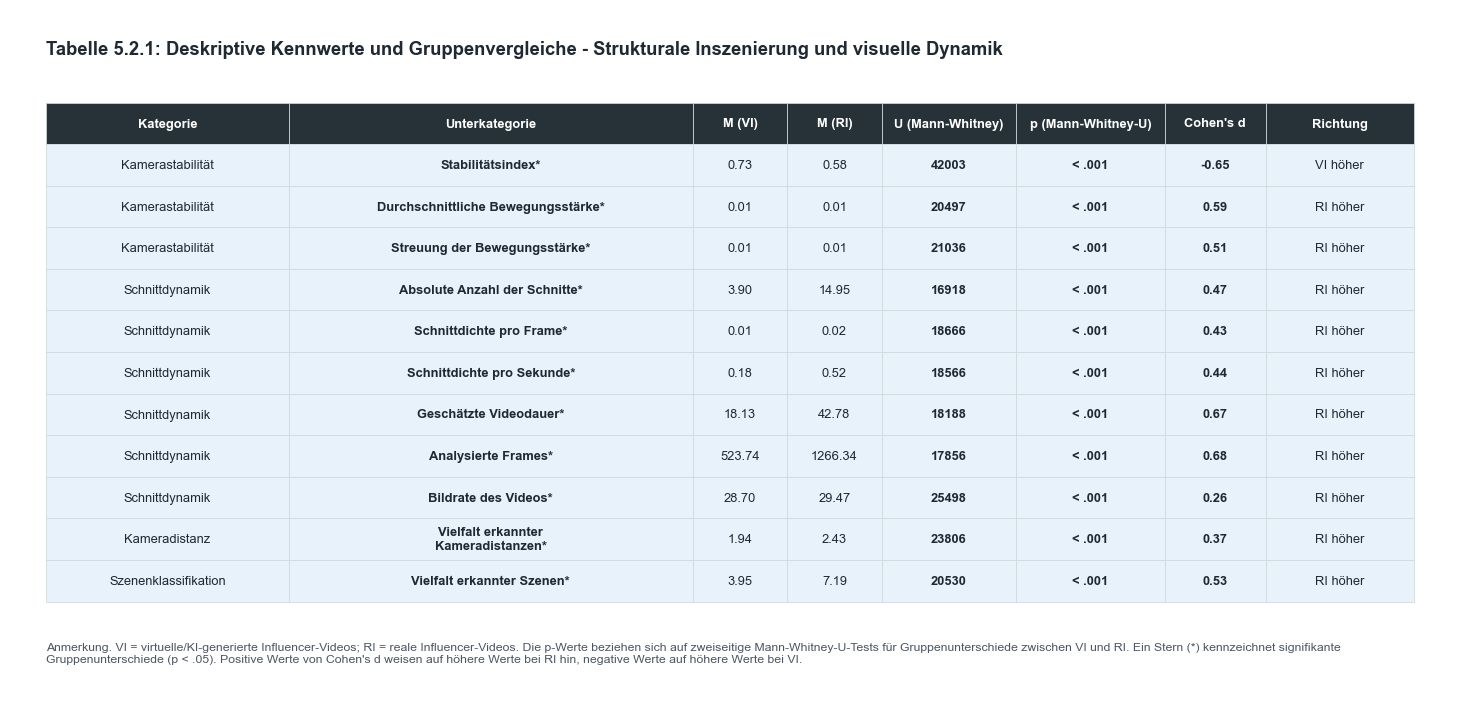

Kategorie,Unterkategorie,M (VI),M (RI),U (Mann-Whitney),p (Mann-Whitney-U),Cohen's d,Richtung
Kamerastabilität,Stabilitätsindex*,0.73,0.58,42003,< .001,-0.65,VI höher
Kamerastabilität,Durchschnittliche Bewegungsstärke*,0.01,0.01,20497,< .001,0.59,RI höher
Kamerastabilität,Streuung der Bewegungsstärke*,0.01,0.01,21036,< .001,0.51,RI höher
Schnittdynamik,Absolute Anzahl der Schnitte*,3.90,14.95,16918,< .001,0.47,RI höher
Schnittdynamik,Schnittdichte pro Frame*,0.01,0.02,18666,< .001,0.43,RI höher
Schnittdynamik,Schnittdichte pro Sekunde*,0.18,0.52,18566,< .001,0.44,RI höher
Schnittdynamik,Geschätzte Videodauer*,18.13,42.78,18188,< .001,0.67,RI höher
Schnittdynamik,Analysierte Frames*,523.74,1266.34,17856,< .001,0.68,RI höher
Schnittdynamik,Bildrate des Videos*,28.70,29.47,25498,< .001,0.26,RI höher
Kameradistanz,Vielfalt erkannter Kameradistanzen*,1.94,2.43,23806,< .001,0.37,RI höher


CSV gespeichert: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_1_strukturale_inszenierung_und_visuelle_dynamik.csv
PNG gespeichert: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_1_strukturale_inszenierung_und_visuelle_dynamik.png


In [5]:
table_521_df, table_521_csv, table_521_png = export_table_bundle(TABLE_SPECS[0], group_diff_df)
display_chapter_table(table_521_df, TABLE_SPECS[0])
print('CSV gespeichert:', table_521_csv)
print('PNG gespeichert:', table_521_png)


## 5.2.2 Bildtechnische Qualität (H2)


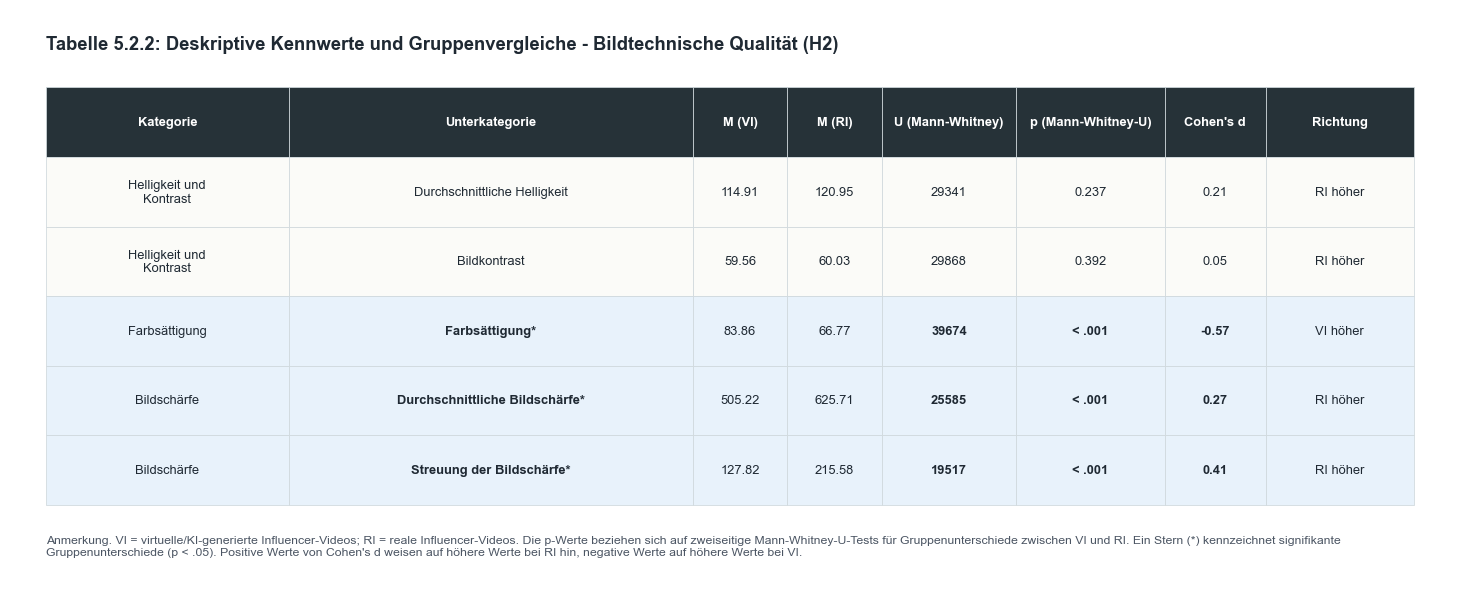

Kategorie,Unterkategorie,M (VI),M (RI),U (Mann-Whitney),p (Mann-Whitney-U),Cohen's d,Richtung
Helligkeit und Kontrast,Durchschnittliche Helligkeit,114.91,120.95,29341,0.237,0.21,RI höher
Helligkeit und Kontrast,Bildkontrast,59.56,60.03,29868,0.392,0.05,RI höher
Farbsättigung,Farbsättigung*,83.86,66.77,39674,< .001,-0.57,VI höher
Bildschärfe,Durchschnittliche Bildschärfe*,505.22,625.71,25585,< .001,0.27,RI höher
Bildschärfe,Streuung der Bildschärfe*,127.82,215.58,19517,< .001,0.41,RI höher


CSV gespeichert: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_2_bildtechnische_qualität.csv
PNG gespeichert: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_2_bildtechnische_qualität.png


In [6]:
table_522_df, table_522_csv, table_522_png = export_table_bundle(TABLE_SPECS[1], group_diff_df)
display_chapter_table(table_522_df, TABLE_SPECS[1])
print('CSV gespeichert:', table_522_csv)
print('PNG gespeichert:', table_522_png)


## 5.2.3 Ästhetik (H3)


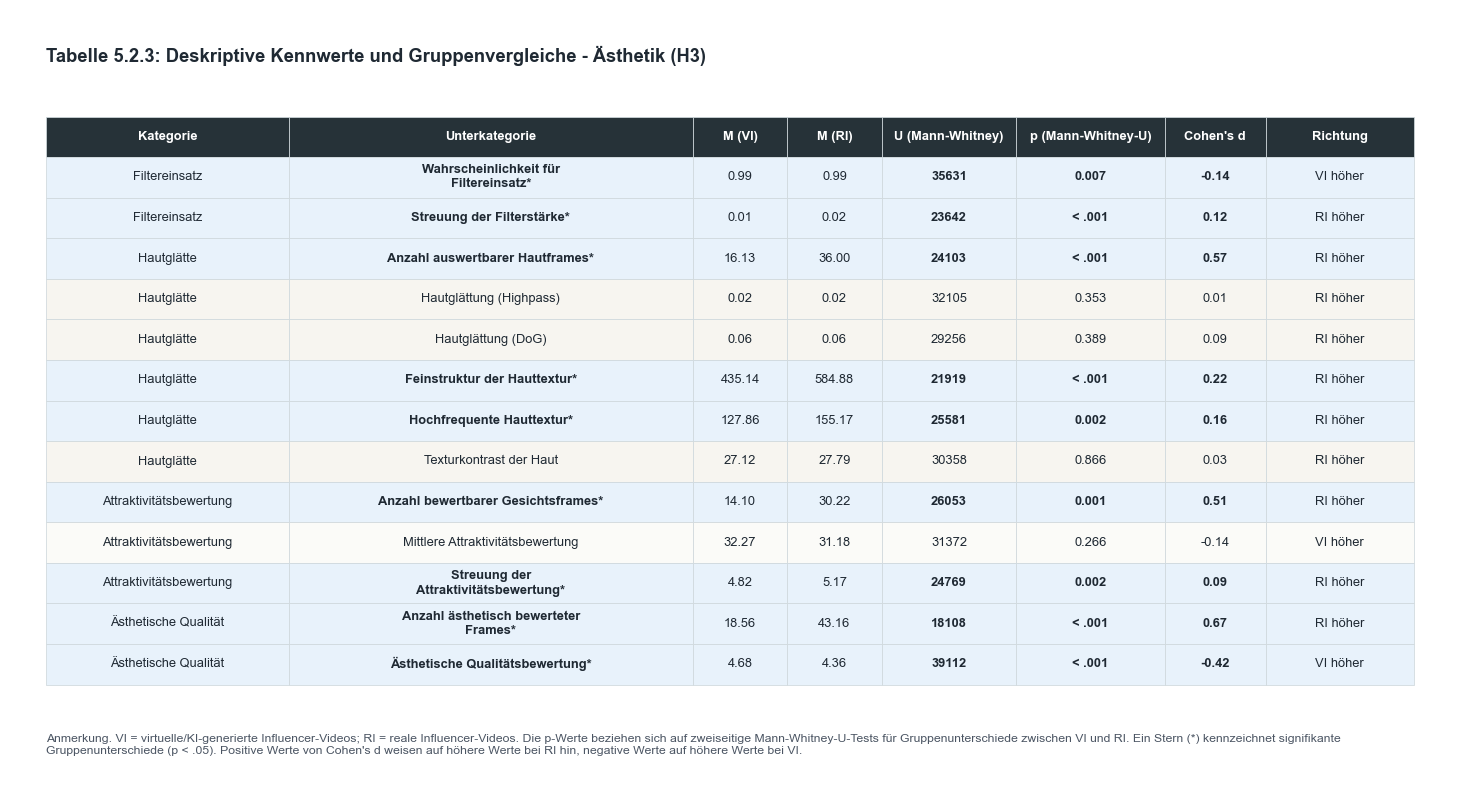

Kategorie,Unterkategorie,M (VI),M (RI),U (Mann-Whitney),p (Mann-Whitney-U),Cohen's d,Richtung
Filtereinsatz,Wahrscheinlichkeit für Filtereinsatz*,0.99,0.99,35631,0.007,-0.14,VI höher
Filtereinsatz,Streuung der Filterstärke*,0.01,0.02,23642,< .001,0.12,RI höher
Hautglätte,Anzahl auswertbarer Hautframes*,16.13,36.00,24103,< .001,0.57,RI höher
Hautglätte,Hautglättung (Highpass),0.02,0.02,32105,0.353,0.01,RI höher
Hautglätte,Hautglättung (DoG),0.06,0.06,29256,0.389,0.09,RI höher
Hautglätte,Feinstruktur der Hauttextur*,435.14,584.88,21919,< .001,0.22,RI höher
Hautglätte,Hochfrequente Hauttextur*,127.86,155.17,25581,0.002,0.16,RI höher
Hautglätte,Texturkontrast der Haut,27.12,27.79,30358,0.866,0.03,RI höher
Attraktivitätsbewertung,Anzahl bewertbarer Gesichtsframes*,14.10,30.22,26053,0.001,0.51,RI höher
Attraktivitätsbewertung,Mittlere Attraktivitätsbewertung,32.27,31.18,31372,0.266,-0.14,VI höher


CSV gespeichert: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_3_aesthetik.csv
PNG gespeichert: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_3_aesthetik.png


In [7]:
table_523_df, table_523_csv, table_523_png = export_table_bundle(TABLE_SPECS[2], group_diff_df)
display_chapter_table(table_523_df, TABLE_SPECS[2])
print('CSV gespeichert:', table_523_csv)
print('PNG gespeichert:', table_523_png)


## 5.2.4 Emotion und soziale Präsenz (H4)


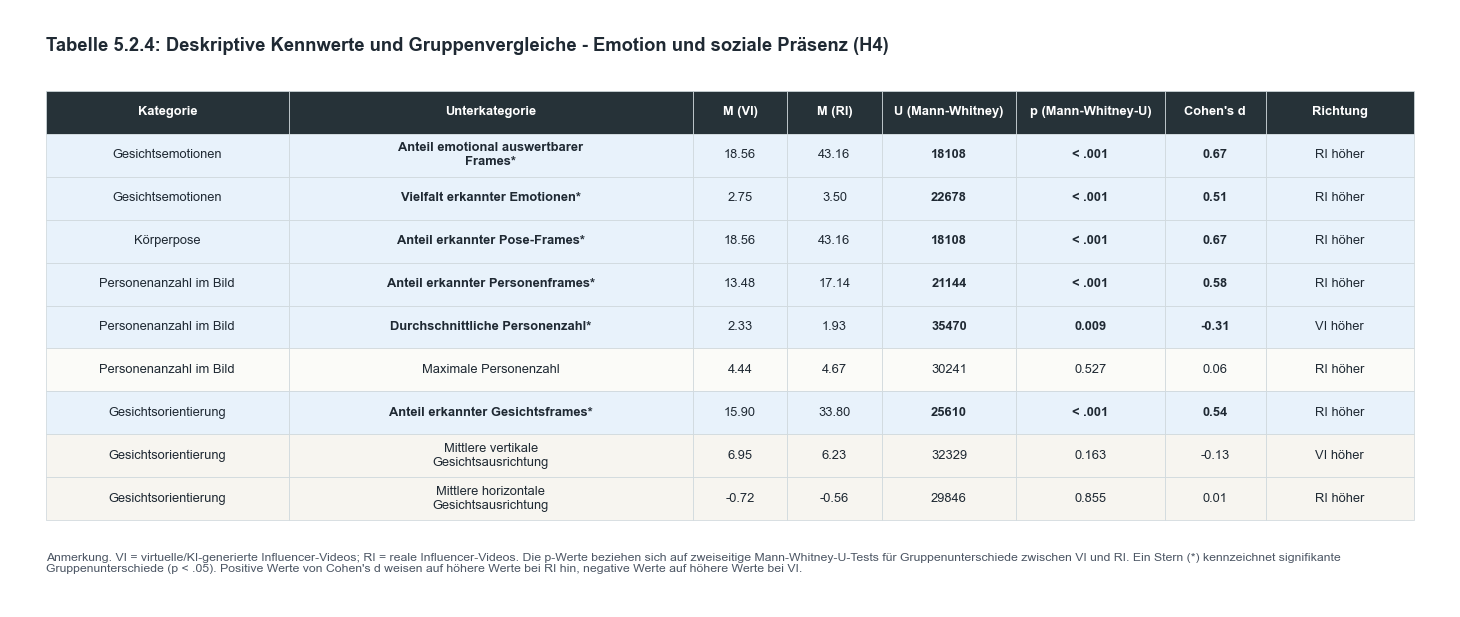

Kategorie,Unterkategorie,M (VI),M (RI),U (Mann-Whitney),p (Mann-Whitney-U),Cohen's d,Richtung
Gesichtsemotionen,Anteil emotional auswertbarer Frames*,18.56,43.16,18108,< .001,0.67,RI höher
Gesichtsemotionen,Vielfalt erkannter Emotionen*,2.75,3.50,22678,< .001,0.51,RI höher
Körperpose,Anteil erkannter Pose-Frames*,18.56,43.16,18108,< .001,0.67,RI höher
Personenanzahl im Bild,Anteil erkannter Personenframes*,13.48,17.14,21144,< .001,0.58,RI höher
Personenanzahl im Bild,Durchschnittliche Personenzahl*,2.33,1.93,35470,0.009,-0.31,VI höher
Personenanzahl im Bild,Maximale Personenzahl,4.44,4.67,30241,0.527,0.06,RI höher
Gesichtsorientierung,Anteil erkannter Gesichtsframes*,15.90,33.80,25610,< .001,0.54,RI höher
Gesichtsorientierung,Mittlere vertikale Gesichtsausrichtung,6.95,6.23,32329,0.163,-0.13,VI höher
Gesichtsorientierung,Mittlere horizontale Gesichtsausrichtung,-0.72,-0.56,29846,0.855,0.01,RI höher


CSV gespeichert: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_4_emotion_und_soziale_praesenz.csv
PNG gespeichert: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_4_emotion_und_soziale_praesenz.png


In [8]:
table_524_df, table_524_csv, table_524_png = export_table_bundle(TABLE_SPECS[3], group_diff_df)
display_chapter_table(table_524_df, TABLE_SPECS[3])
print('CSV gespeichert:', table_524_csv)
print('PNG gespeichert:', table_524_png)


## 5.2.5 Signifikante Korrelationen mit Engagement

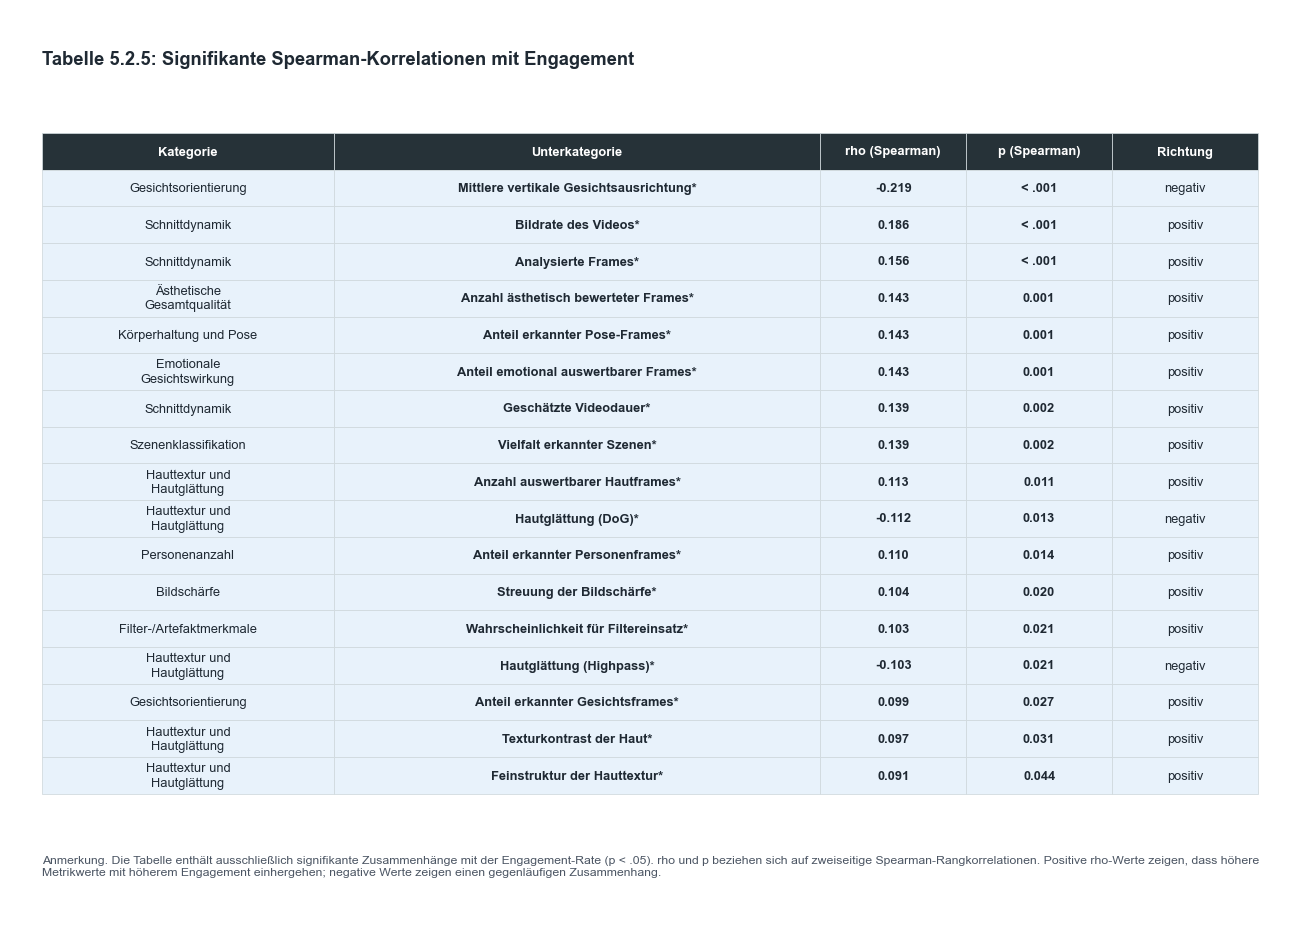

Kategorie,Unterkategorie,rho (Spearman),p (Spearman),Richtung
Gesichtsorientierung,Mittlere vertikale Gesichtsausrichtung*,-0.219,< .001,negativ
Schnittdynamik,Bildrate des Videos*,0.186,< .001,positiv
Schnittdynamik,Analysierte Frames*,0.156,< .001,positiv
Ästhetische Gesamtqualität,Anzahl ästhetisch bewerteter Frames*,0.143,0.001,positiv
Körperhaltung und Pose,Anteil erkannter Pose-Frames*,0.143,0.001,positiv
Emotionale Gesichtswirkung,Anteil emotional auswertbarer Frames*,0.143,0.001,positiv
Schnittdynamik,Geschätzte Videodauer*,0.139,0.002,positiv
Szenenklassifikation,Vielfalt erkannter Szenen*,0.139,0.002,positiv
Hauttextur und Hautglättung,Anzahl auswertbarer Hautframes*,0.113,0.011,positiv
Hauttextur und Hautglättung,Hautglättung (DoG)*,-0.112,0.013,negativ


CSV gespeichert: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_5_signifikante_engagement_korrelationen.csv
PNG gespeichert: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_5_signifikante_engagement_korrelationen.png


In [9]:
engagement_corr_sig_df, engagement_corr_csv, engagement_corr_png = export_correlation_table_bundle(engagement_corr_df)
display_correlation_table(engagement_corr_sig_df)
print('CSV gespeichert:', engagement_corr_csv)
print('PNG gespeichert:', engagement_corr_png)


## Exportübersicht


In [10]:
export_overview = pd.DataFrame([
    {'Kapitel': '5.2.1', 'CSV': str(table_521_csv), 'PNG': str(table_521_png)},
    {'Kapitel': '5.2.2', 'CSV': str(table_522_csv), 'PNG': str(table_522_png)},
    {'Kapitel': '5.2.3', 'CSV': str(table_523_csv), 'PNG': str(table_523_png)},
    {'Kapitel': '5.2.4', 'CSV': str(table_524_csv), 'PNG': str(table_524_png)},
    {'Kapitel': '5.2.5', 'CSV': str(engagement_corr_csv), 'PNG': str(engagement_corr_png)},
])
display(
    export_overview.style
    .set_caption('Exportierte Tabellen und Abbildungen')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [('caption-side', 'top'), ('text-align', 'left'), ('font-weight', '700'), ('padding', '0 0 8px 0')]},
        {'selector': 'th', 'props': [('background-color', '#263238'), ('color', 'white'), ('padding', '7px 8px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('border', '1px solid #d7dde1'), ('padding', '6px 8px'), ('text-align', 'center'), ('vertical-align', 'middle')]},
    ])
)


Kapitel,CSV,PNG
5.2.1,/Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_1_strukturale_inszenierung_und_visuelle_dynamik.csv,/Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_1_strukturale_inszenierung_und_visuelle_dynamik.png
5.2.2,/Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_2_bildtechnische_qualität.csv,/Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_2_bildtechnische_qualität.png
5.2.3,/Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_3_aesthetik.csv,/Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_3_aesthetik.png
5.2.4,/Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_4_emotion_und_soziale_praesenz.csv,/Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_4_emotion_und_soziale_praesenz.png
5.2.5,/Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_5_signifikante_engagement_korrelationen.csv,/Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/chapter_tables/5_2_5_signifikante_engagement_korrelationen.png
